# Replication: IISE PG&E Energy Analytics Challenge 2025
## *Hourly-Binned Regression Models Beat Transformers in Load Forecasting*
**Authors:** Millend Roy, Vladimir Pyltsov, Yinbo Hu (Columbia University)

**Replication Pipeline:** 24 Hourly-Binned XGBoost Models, PCA Exogenous Transformation, Lag/Lead Experiments (Table 5), and Year 3 Final Forecast Evaluation (Figures 6 & 7).


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

# Ensure project root and replication folder are in sys.path
cwd = os.getcwd()
project_root = os.path.dirname(cwd) if os.path.basename(cwd) == "replication" else cwd
if project_root not in sys.path:
    sys.path.insert(0, project_root)
rep_dir = os.path.join(project_root, "replication")
if rep_dir not in sys.path:
    sys.path.insert(0, rep_dir)

from replication.config import (
    TEMP_COLS, GHI_COLS, TARGET_COL, OUTPUT_DIR, FIGURES_DIR
)
from replication.data_loader import load_and_preprocess_data
from replication.feature_engineering import (
    compute_vif, PCAExogenousTransformer,
    add_all_lag_lead_configurations, get_feature_list_by_config
)
from replication.model_hourly_xgboost import HourlyXGBoostForecaster
from replication.evaluate import (
    compute_metrics, evaluate_year1_to_year2,
    evaluate_year2_to_year1, evaluate_both_years_cv
)
from replication.visualize import (
    plot_fig1_fig2_load_vs_temp, plot_fig3_pca_variance,
    plot_fig4_weekdays_vs_weekends,
    plot_fig6_final_forecast, plot_fig7_monthly_forecast
)

print("Environment initialized successfully.")
print(f"Project root : {project_root}")
print(f"Output dir   : {OUTPUT_DIR}")
print(f"Figures dir  : {FIGURES_DIR}")


Environment initialized successfully.
Project root : D:\AIO2026\M03
Output dir   : D:\AIO2026\M03\output\replication
Figures dir  : D:\AIO2026\M03\output\replication\figures


C:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Load Data & Calendar Feature Reconstruction
- **Year 1**: 2020 (Leap year, 8,784 hours)
- **Year 2**: 2021 (Standard year, 8,760 hours)
- **Year 3**: 2022 (Test Set, 8,760 hours)
- Reconstructs 12 monthly dummies, weekend indicator (`Is_Weekend`), and US federal holidays (`Is_Holiday`).


In [2]:
train_df, test_df = load_and_preprocess_data(use_cache=True)
print(f"Train dataset shape (Years 1 & 2): {train_df.shape}")
print(f"Test dataset shape (Year 3)      : {test_df.shape}")
train_df.head(5)


Train dataset shape (Years 1 & 2): (17544, 32)
Test dataset shape (Year 3)      : (8760, 32)


,Year,Month,Day,Hour,Load,Site-1 Temp,Site-2 Temp,Site-3 Temp,Site-4 Temp,Site-5 Temp,...,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
0,1,1,1,1,1997,8.0,8.2,5.3,9.4,8.1,...,0,0,0,0,0,0,0,0,0,0
1,1,1,1,2,1921,8.3,8.6,5.2,8.6,7.1,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,3,1861,8.1,8.8,5.1,8.7,6.2,...,0,0,0,0,0,0,0,0,0,0
3,1,1,1,4,1833,7.6,8.1,4.3,8.5,6.0,...,0,0,0,0,0,0,0,0,0,0
4,1,1,1,5,1847,7.3,7.5,4.0,8.6,6.9,...,0,0,0,0,0,0,0,0,0,0


### 2. Descriptive Statistics (Replicating Table 1)
Computes Mean ($\mu$), Standard Deviation ($\sigma$), Median, Min, Max, Skewness ($\gamma_1$), and Kurtosis ($\gamma_2$) for Load, 5 Temperature sites, and 5 Solar GHI sites across Year 1 and Year 2.


In [3]:
cols = ['Load'] + TEMP_COLS + GHI_COLS
stats_records = []
for yr in [1, 2]:
    sub = train_df[train_df['Year'] == yr]
    for name, func in [
        ('Mean (mu)', 'mean'),
        ('Std (sigma)', 'std'),
        ('Median', 'median'),
        ('Min', 'min'),
        ('Max', 'max'),
        ('Skew (gamma1)', 'skew'),
        ('Kurt (gamma2)', 'kurt')
    ]:
        row = {'Metric': name, 'Year': f'Year {yr}'}
        for c in cols:
            val = getattr(sub[c], func)()
            row[c] = round(float(val), 2)
        stats_records.append(row)

df_table1 = pd.DataFrame(stats_records)
display(df_table1)


,Metric,Year,Load,Site-1 Temp,Site-2 Temp,Site-3 Temp,Site-4 Temp,Site-5 Temp,Site-1 GHI,Site-2 GHI,Site-3 GHI,Site-4 GHI,Site-5 GHI
0,Mean (mu),Year 1,2162.82,17.31,17.17,18.27,17.72,17.60,225.80,222.47,226.91,227.06,228.39
1,Std (sigma),Year 1,465.77,4.86,4.51,7.36,4.75,5.84,305.18,301.51,307.34,306.63,308.05
2,Median,Year 1,2072.00,17.50,17.40,17.30,17.80,17.30,12.00,12.00,12.00,12.00,13.00
3,Min,Year 1,1101.00,1.90,2.90,-0.50,2.60,0.90,0.00,0.00,0.00,0.00,0.00
4,Max,Year 1,4397.00,36.60,31.90,43.00,36.60,39.70,1037.00,1028.00,1041.00,1047.00,1049.00
5,Skew (gamma1),Year 1,1.18,0.09,-0.00,0.45,0.20,0.42,1.07,1.09,1.09,1.08,1.08
6,Kurt (gamma2),Year 1,2.10,-0.14,-0.33,-0.26,-0.02,0.02,-0.25,-0.19,-0.20,-0.23,-0.23
7,Mean (mu),Year 2,2145.42,16.72,16.47,17.80,17.06,16.84,221.24,218.81,225.35,223.31,225.08
8,Std (sigma),Year 2,406.48,4.48,4.18,7.02,4.35,5.37,301.69,298.73,306.39,304.56,306.06
9,Median,Year 2,2096.00,16.60,16.40,17.20,17.00,16.60,12.00,11.00,11.00,11.00,11.00


### 3. Exploratory Visualizations (Figures 1, 2, 3, 4)
- **Figures 1 & 2**: Load vs Site 5 Temperature at Hour 4:00 AM for Year 1 and Year 2.
- **Figure 3**: PCA Explained Variance for Temperature and GHI.
- **Figure 4**: Weekdays vs Weekends load profile (first 4 weeks).


=== Figure 1 & 2: Load vs Site-5 Temp (Hour 4:00) ===


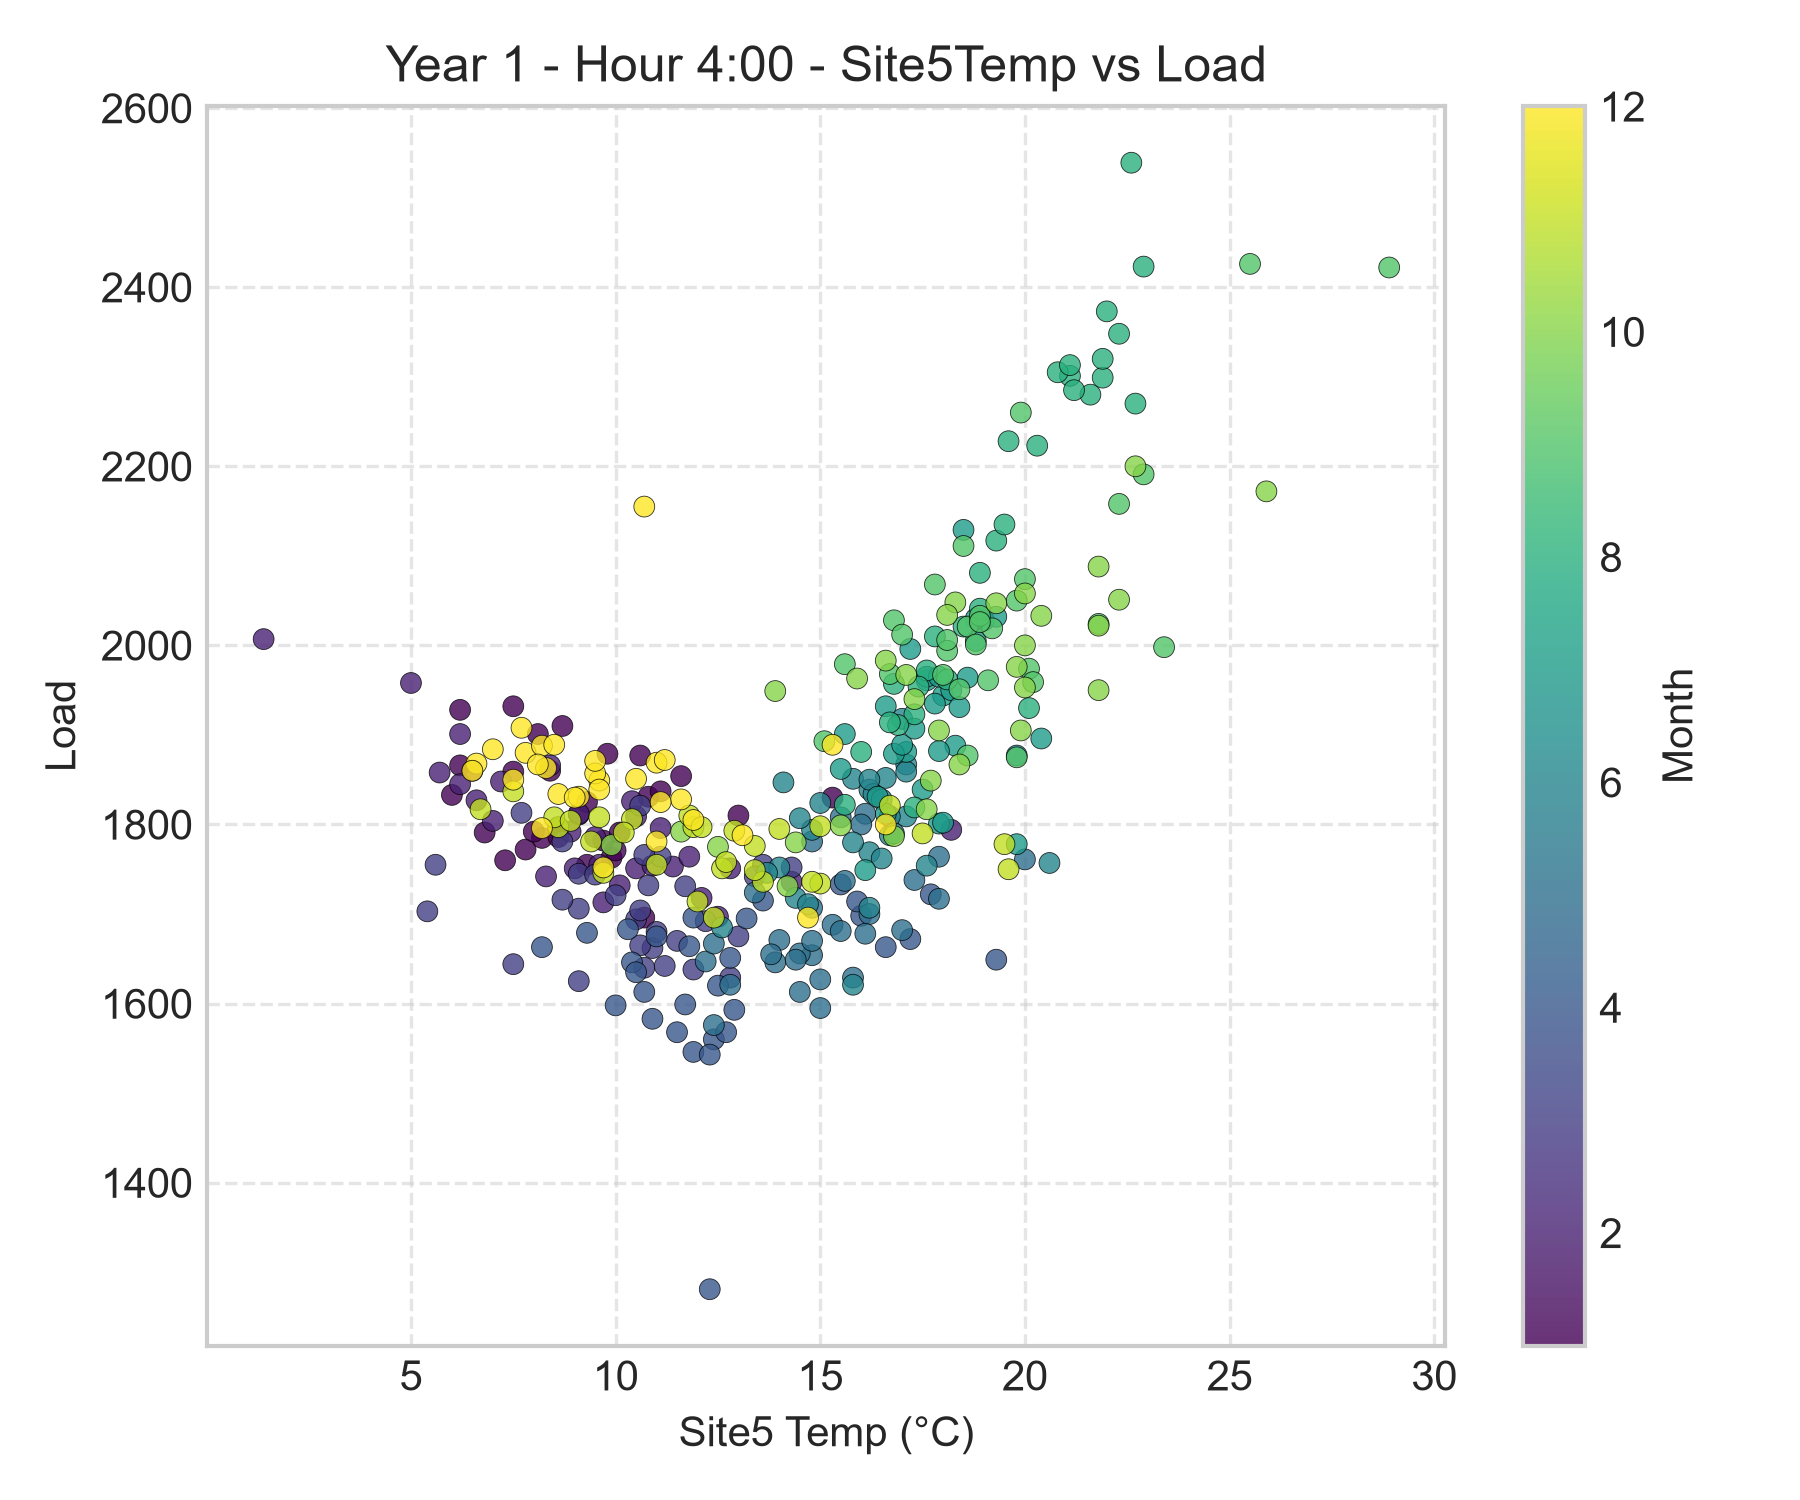

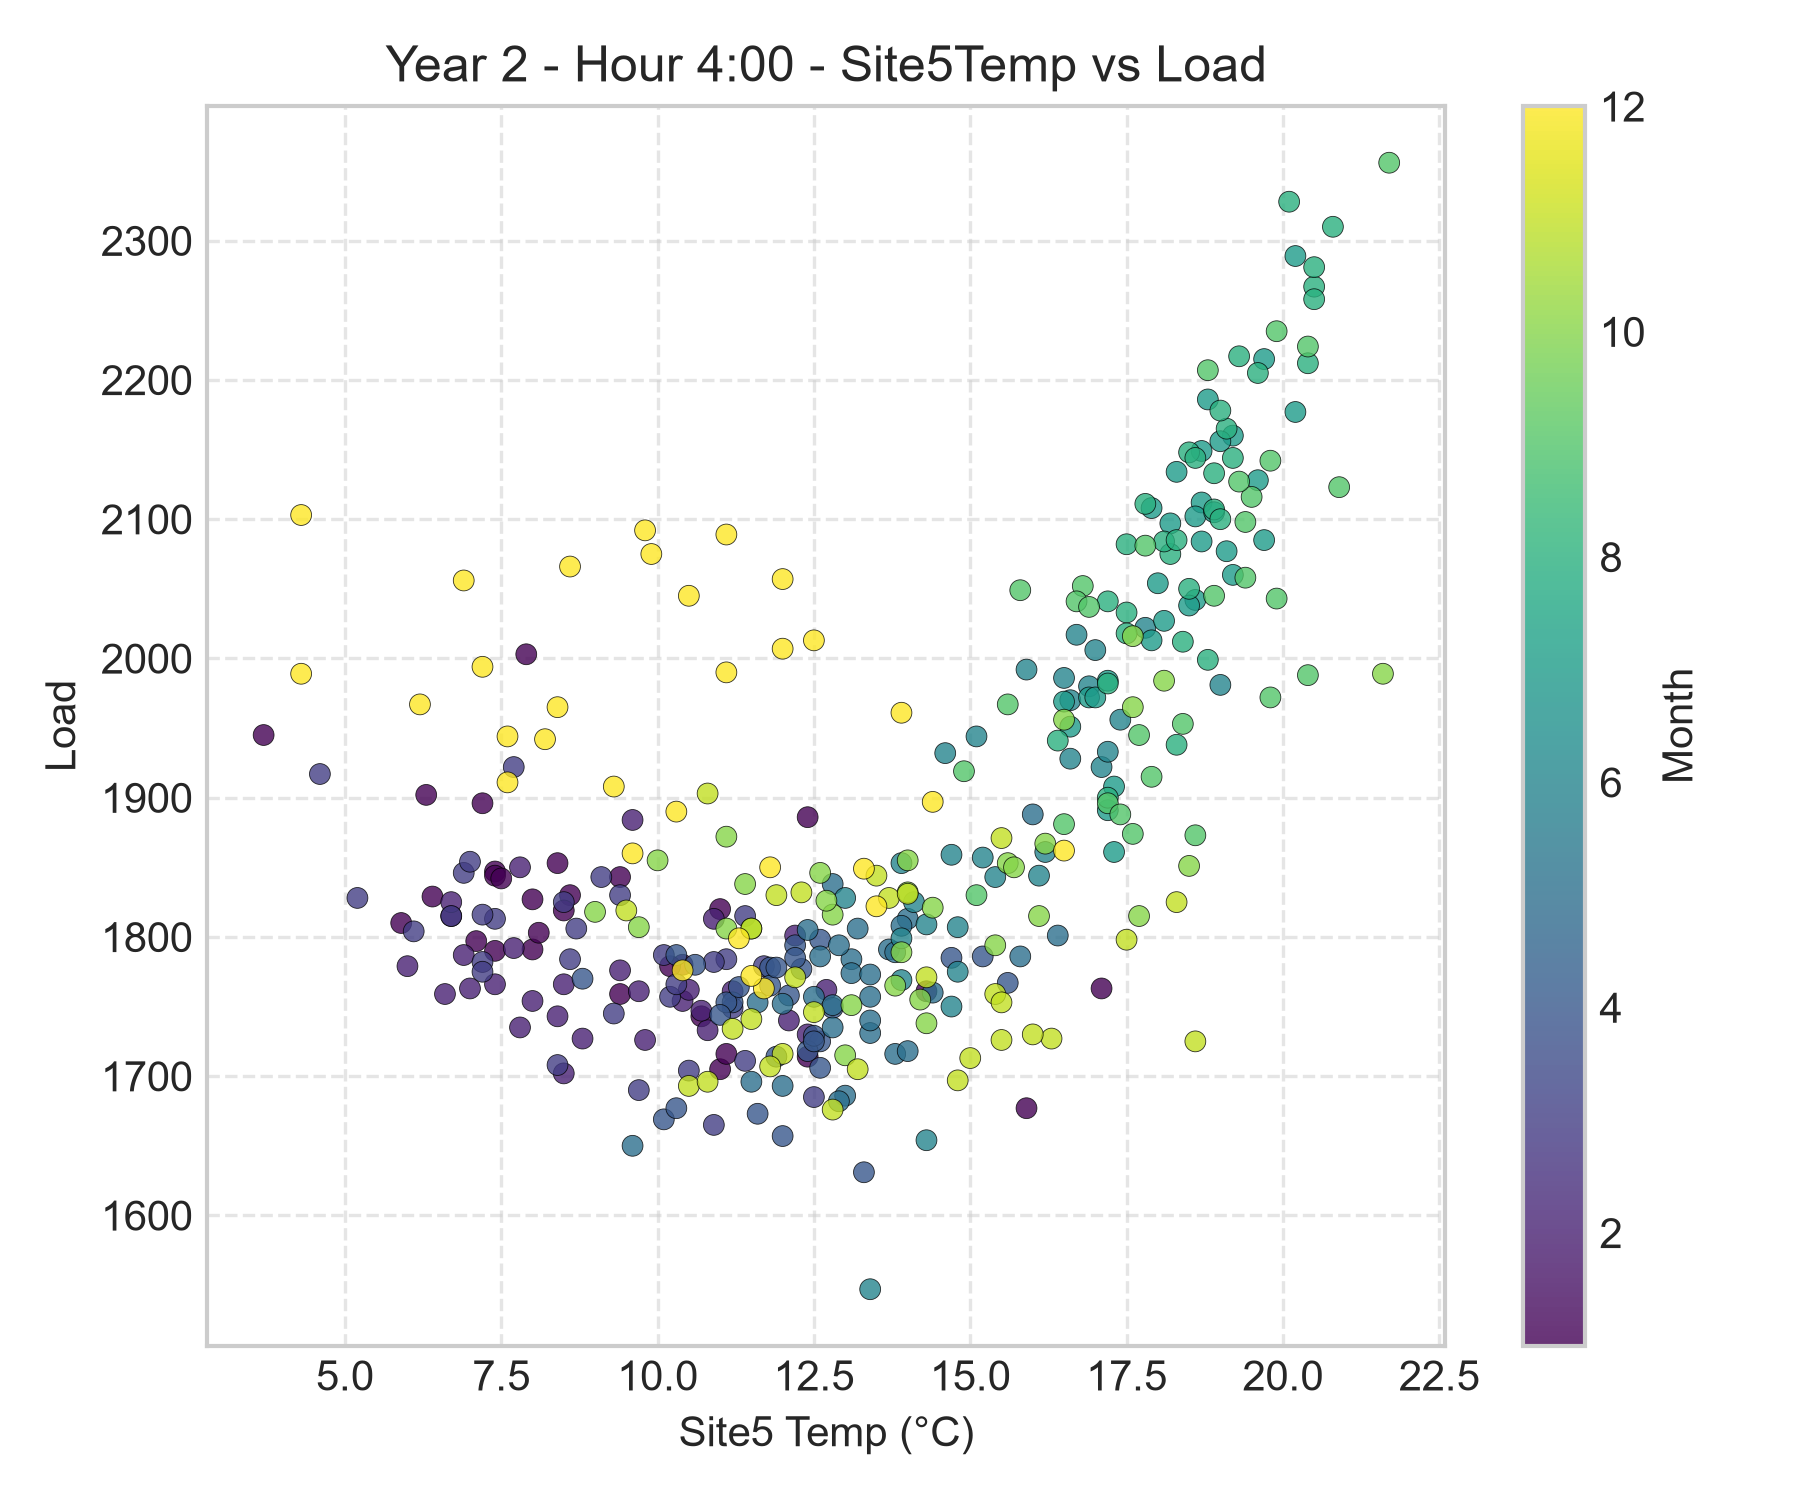

=== Figure 3: PCA Variance Ratio per Component ===


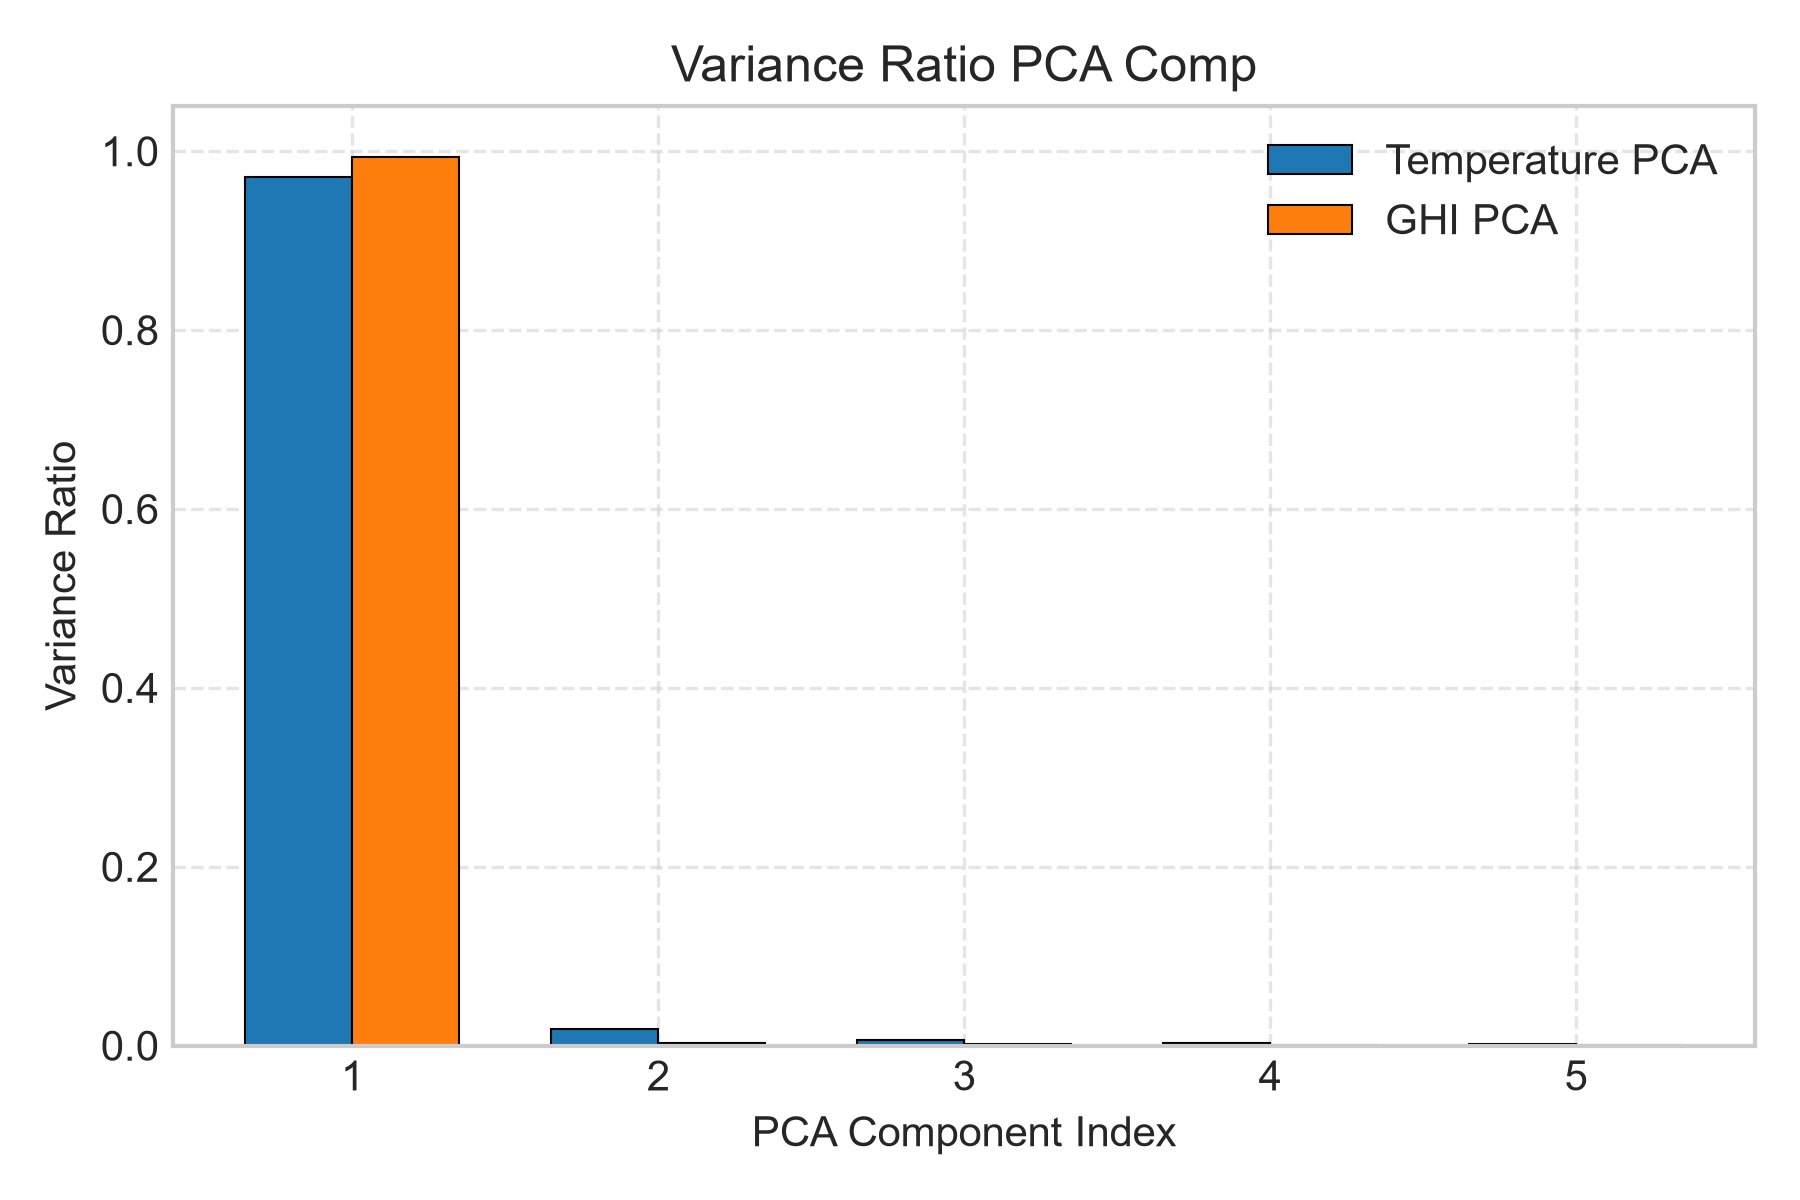

=== Figure 4: Weekdays vs Weekends Hourly Profile ===


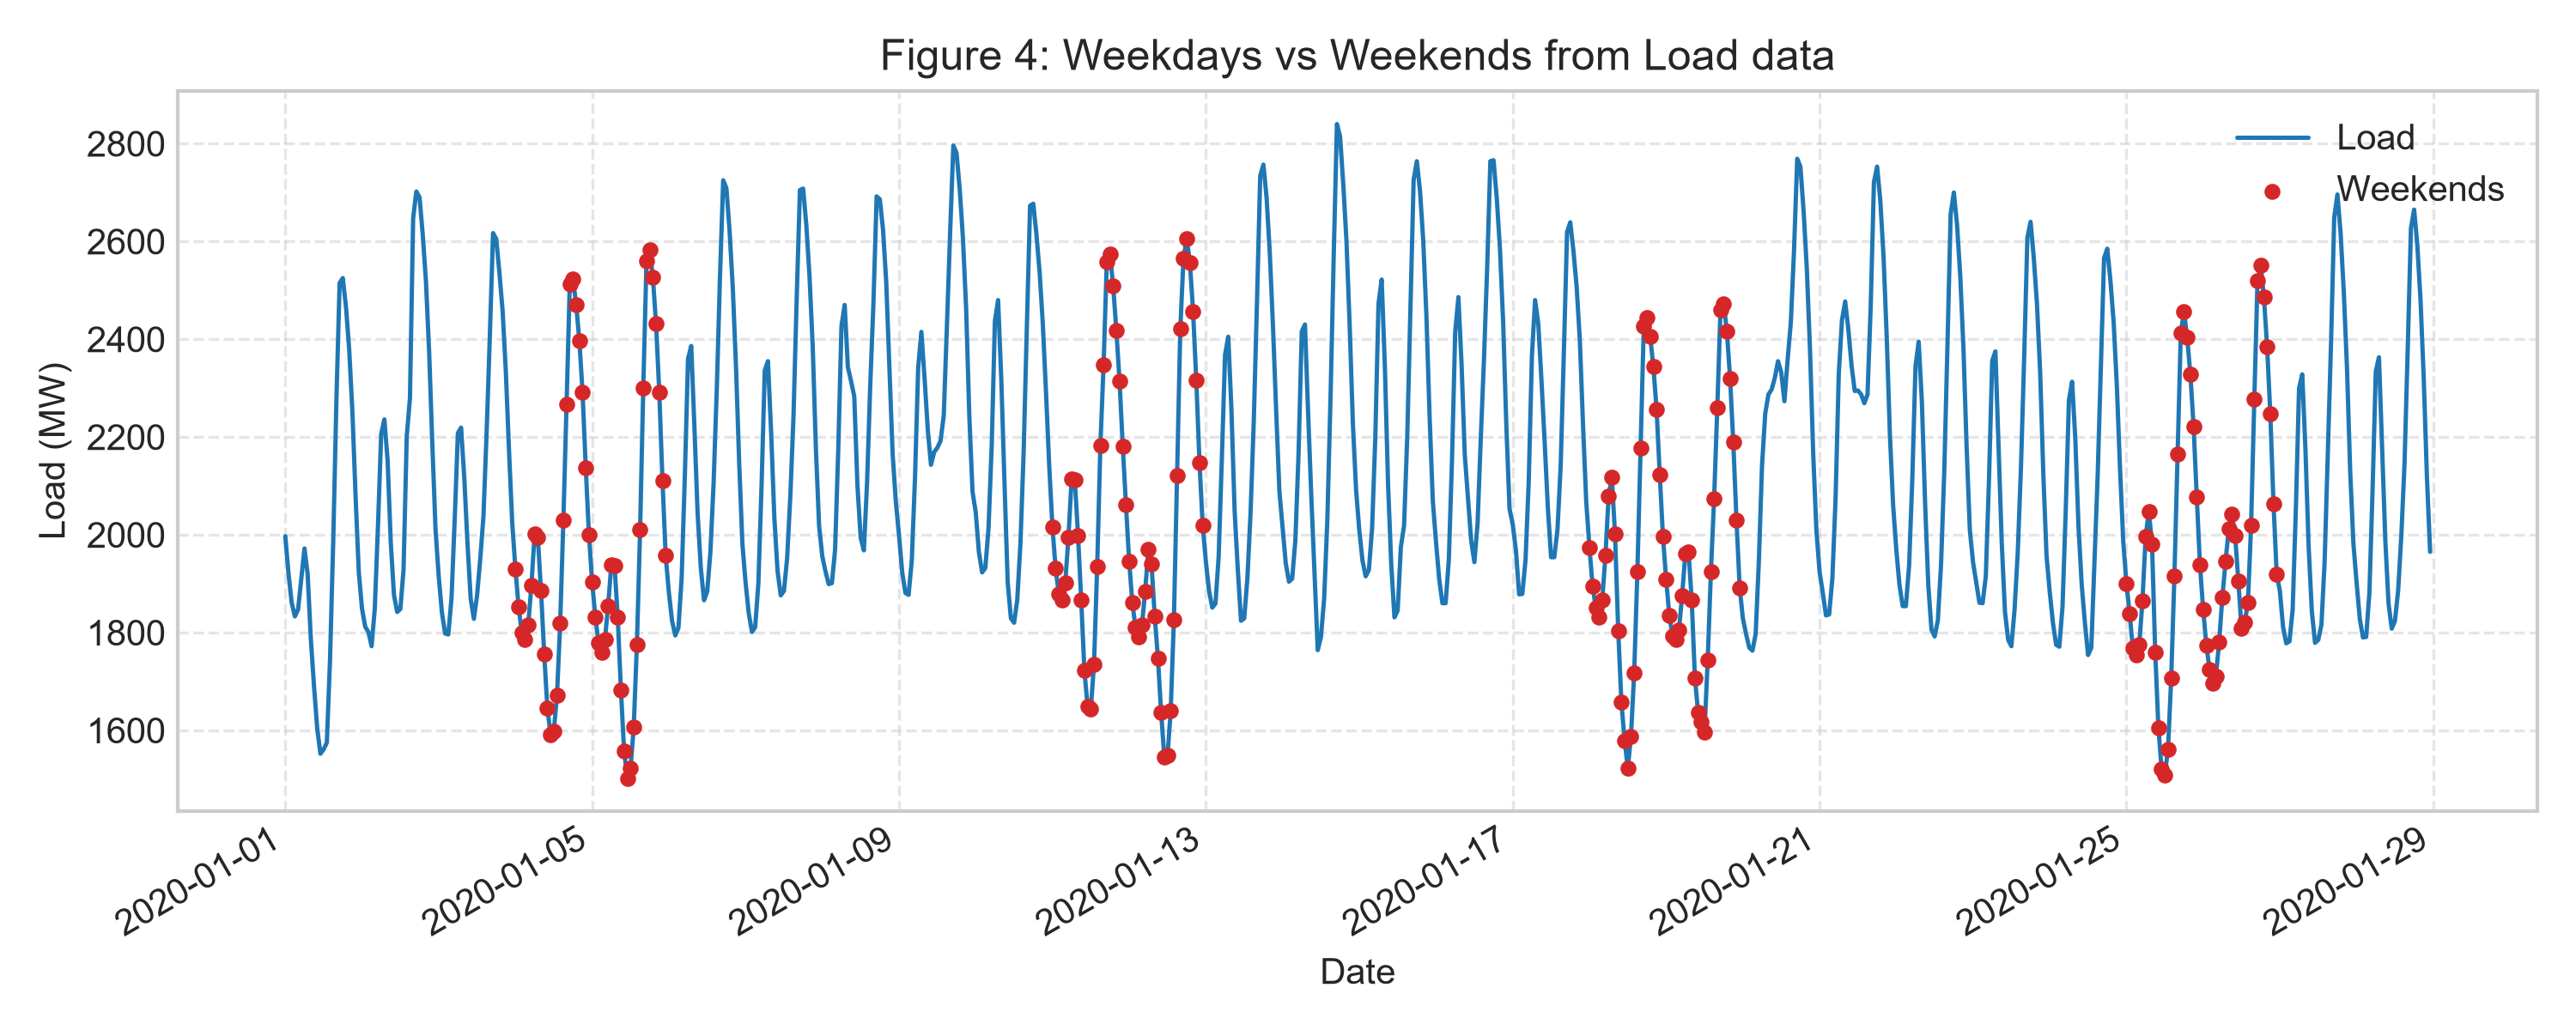

In [4]:
# Generate high-resolution figures to disk
plot_fig1_fig2_load_vs_temp(train_df, FIGURES_DIR)
plot_fig3_pca_variance(train_df, TEMP_COLS, GHI_COLS, FIGURES_DIR)
plot_fig4_weekdays_vs_weekends(train_df, FIGURES_DIR)

# Display generated figures inline
fig1_path = os.path.join(FIGURES_DIR, "Figure_1_Load_vs_Site5Temp_Year1.png")
fig2_path = os.path.join(FIGURES_DIR, "Figure_2_Load_vs_Site5Temp_Year2.png")
fig3_path = os.path.join(FIGURES_DIR, "Figure_3_PCA_Components.png")
fig4_path = os.path.join(FIGURES_DIR, "Figure_4_Weekdays_vs_Weekends.png")

print("=== Figure 1 & 2: Load vs Site-5 Temp (Hour 4:00) ===")
display(Image(filename=fig1_path, width=450))
display(Image(filename=fig2_path, width=450))

print("=== Figure 3: PCA Variance Ratio per Component ===")
display(Image(filename=fig3_path, width=500))

print("=== Figure 4: Weekdays vs Weekends Hourly Profile ===")
display(Image(filename=fig4_path, width=800))


### 4. PCA Dimensionality Reduction & VIF Multicollinearity Analysis (Tables 2 & 3)
- Compresses 5 collinear temperature sensors into `PCA_Temp` (>97% variance captured).
- Compresses 5 collinear solar GHI sensors into `PCA_GHI` (>99% variance captured).
- Eliminates extreme Variance Inflation Factors (VIF > 100 reduced to VIF < 5).


In [5]:
pca_trans = PCAExogenousTransformer()
train_df = pca_trans.fit_transform(train_df)
test_df = pca_trans.transform(test_df)

var_dict = pca_trans.get_explained_variance()
print(f"Explained Variance Ratio PCA_Temp: {var_dict['PCA_Temp']:.4f}")
print(f"Explained Variance Ratio PCA_GHI : {var_dict['PCA_GHI']:.4f}")

print("\n=== Table 2 Replication: VIF Before PCA (Temperature) ===")
display(compute_vif(train_df, TEMP_COLS + [TARGET_COL]))

print("\n=== Table 2 Replication: VIF Before PCA (GHI) ===")
display(compute_vif(train_df, GHI_COLS + [TARGET_COL]))

print("\n=== Table 3 Replication: VIF After PCA ===")
display(compute_vif(train_df, ['PCA_Temp', 'PCA_GHI', TARGET_COL]))


Explained Variance Ratio PCA_Temp: 0.9705
Explained Variance Ratio PCA_GHI : 0.9939

=== Table 2 Replication: VIF Before PCA (Temperature) ===


,Feature,VIF
0,Site-1 Temp,31.74
1,Site-2 Temp,29.12
2,Site-3 Temp,17.08
3,Site-4 Temp,52.70
4,Site-5 Temp,48.78
5,Load,1.20



=== Table 2 Replication: VIF Before PCA (GHI) ===


,Feature,VIF
0,Site-1 GHI,180.98
1,Site-2 GHI,122.91
2,Site-3 GHI,93.43
3,Site-4 GHI,692.16
4,Site-5 GHI,1055.70
5,Load,1.01



=== Table 3 Replication: VIF After PCA ===


,Feature,VIF
0,PCA_Temp,2.47
1,PCA_GHI,2.07
2,Load,1.49


### 5. Exogenous Lag & Lead Feature Engineering (Table 5)
Constructs lagged (t-1, t-2, t-3, t-5) and lead (t+1, t+2) features of `PCA_Temp` and `PCA_GHI`.


In [6]:
train_df = add_all_lag_lead_configurations(train_df)
test_df = add_all_lag_lead_configurations(test_df)
print(f"Total features count after lag/lead augmentation: {train_df.shape[1]}")
sample_cols = ['Date', 'Hour', 'PCA_Temp', 'PCA_Temp_Lag1', 'PCA_Temp_Lag2', 'PCA_GHI', 'PCA_GHI_Lag1']
train_df[sample_cols].head(5)


Total features count after lag/lead augmentation: 46


,Date,Hour,PCA_Temp,PCA_Temp_Lag1,PCA_Temp_Lag2,PCA_GHI,PCA_GHI_Lag1
0,2020-01-01,1,-21.507930,-21.507930,-21.507930,-501.898296,-501.898296
1,2020-01-01,2,-22.080623,-21.507930,-21.507930,-501.898296,-501.898296
2,2020-01-01,3,-22.530378,-22.080623,-21.507930,-501.898296,-501.898296
3,2020-01-01,4,-23.622944,-22.530378,-22.080623,-501.898296,-501.898296
4,2020-01-01,5,-23.673559,-23.622944,-22.530378,-501.898296,-501.898296


### 6. Replicating Table 5: 24-Hourly XGBoost Configurations
Evaluates the 4 paper configurations:
1. `Baseline` (PCA_Temp, PCA_GHI, Calendar)
2. `Lag1` (+ Lag1)
3. `Lag2` (+ Lag1, Lag2)
4. `Lead1` (+ Lead1)

Tested under:
- **Year 1 -> Year 2**: Train on 2020, Evaluate on 2021
- **Year 2 -> Year 1**: Train on 2021, Evaluate on 2020
- **5-Fold Cross-Validation**: Walk-forward validation across both years


In [7]:
configs = ['Baseline', 'Lag1', 'Lag2', 'Lead1']
records = []

print("Evaluating Original Paper Configurations...")
for cfg in configs:
    feats = get_feature_list_by_config(cfg)
    m_y1_y2, _ = evaluate_year1_to_year2(train_df, feats, tune_trials=0)
    m_y2_y1, _ = evaluate_year2_to_year1(train_df, feats, tune_trials=0)
    m_cv, _, _ = evaluate_both_years_cv(train_df, feats, n_splits=5, tune_trials=0)

    records.append({
        'Configuration': cfg,
        'Y1->Y2 RMSE (MW)': round(m_y1_y2['RMSE'], 2),
        'Y1->Y2 MAPE (%)': round(m_y1_y2['MAPE'], 2),
        'Y2->Y1 RMSE (MW)': round(m_y2_y1['RMSE'], 2),
        'Y2->Y1 MAPE (%)': round(m_y2_y1['MAPE'], 2),
        '5-Fold CV RMSE (MW)': round(m_cv['RMSE'], 2),
        '5-Fold CV MAPE (%)': round(m_cv['MAPE'], 2)
    })

df_table5 = pd.DataFrame(records)
print("\n" + "=" * 80)
print(" REPLICATED TABLE 5 (XGBOOST CONFIGURATIONS)")
print("=" * 80)
display(df_table5)

table5_path = os.path.join(OUTPUT_DIR, "table_5_replicated.csv")
df_table5.to_csv(table5_path, index=False)
print(f"Table 5 successfully saved to: {table5_path}")


Evaluating Original Paper Configurations...



 REPLICATED TABLE 5 (XGBOOST CONFIGURATIONS)


,Configuration,Y1->Y2 RMSE (MW),Y1->Y2 MAPE (%),Y2->Y1 RMSE (MW),Y2->Y1 MAPE (%),5-Fold CV RMSE (MW),5-Fold CV MAPE (%)
0,Baseline,157.74,5.35,178.74,5.61,257.91,6.88
1,Lag1,160.81,5.40,180.19,5.69,255.55,6.85
2,Lag2,159.01,5.35,179.65,5.69,253.67,6.79
3,Lead1,161.21,5.39,178.81,5.64,254.56,6.80


Table 5 successfully saved to: D:\AIO2026\M03\output\replication\table_5_replicated.csv


### 7. Train Final Paper Champion Model (Lag1) on Full 2-Year Dataset & Forecast Year 3
- Trains 24 hourly-binned XGBoost models on the combined 17,544 hours of Years 1 & 2.
- Evaluates on the unseen Year 3 test set (8,760 hours).
- Computes $R^2$, RMSE, MAPE, and sMAPE against Year 3 true load.


In [8]:
lag1_feats = get_feature_list_by_config('Lag1')
print(f"Features in Champion Model ({len(lag1_feats)}):")
print(lag1_feats)

print("\nTraining 24 Hourly XGBoost Forecaster on Full 2-Year Dataset...")
forecaster = HourlyXGBoostForecaster()
forecaster.fit(train_df, lag1_feats)

print("Generating predictions for Year 3 (Test Set)...")
y3_preds = forecaster.predict(test_df, lag1_feats)

m_y3 = compute_metrics(test_df[TARGET_COL].values, y3_preds)
print("\n" + "=" * 60)
print(" YEAR 3 (TEST SET) REPLICATION METRICS")
print("=" * 60)
print(f"  R2 Score : {m_y3['R2']:.4f}")
print(f"  RMSE     : {m_y3['RMSE']:.2f} MW")
print(f"  MAPE     : {m_y3['MAPE']:.2f}%")
print(f"  sMAPE    : {m_y3['sMAPE']:.2f}%")
print("=" * 60)

# Export predictions to output
pred_df = test_df[['Date', 'Hour', TARGET_COL]].copy()
pred_df['Predicted_Load'] = y3_preds
pred_path = os.path.join(OUTPUT_DIR, "predictions_replication_year3.csv")
pred_df.to_csv(pred_path, index=False)
print(f"Predictions exported to: {pred_path}")


Features in Champion Model (18):
['PCA_Temp', 'PCA_GHI', 'Is_Weekend', 'Is_Holiday', 'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12', 'PCA_Temp_Lag1', 'PCA_GHI_Lag1']

Training 24 Hourly XGBoost Forecaster on Full 2-Year Dataset...


Generating predictions for Year 3 (Test Set)...

 YEAR 3 (TEST SET) REPLICATION METRICS
  R2 Score : 0.8734
  RMSE     : 171.66 MW
  MAPE     : 5.41%
  sMAPE    : 5.48%
Predictions exported to: D:\AIO2026\M03\output\replication\predictions_replication_year3.csv


### 8. Final Forecast Visualizations (Figures 6 & 7)
- **Figure 6**: Complete Year 3 (2022) Hourly Load Forecast.
- **Figure 7**: 12-Month Grid with 24-hour Moving Average overlay in Red.


=== Figure 6: Final Load Forecast (Year 3 / 2022) ===


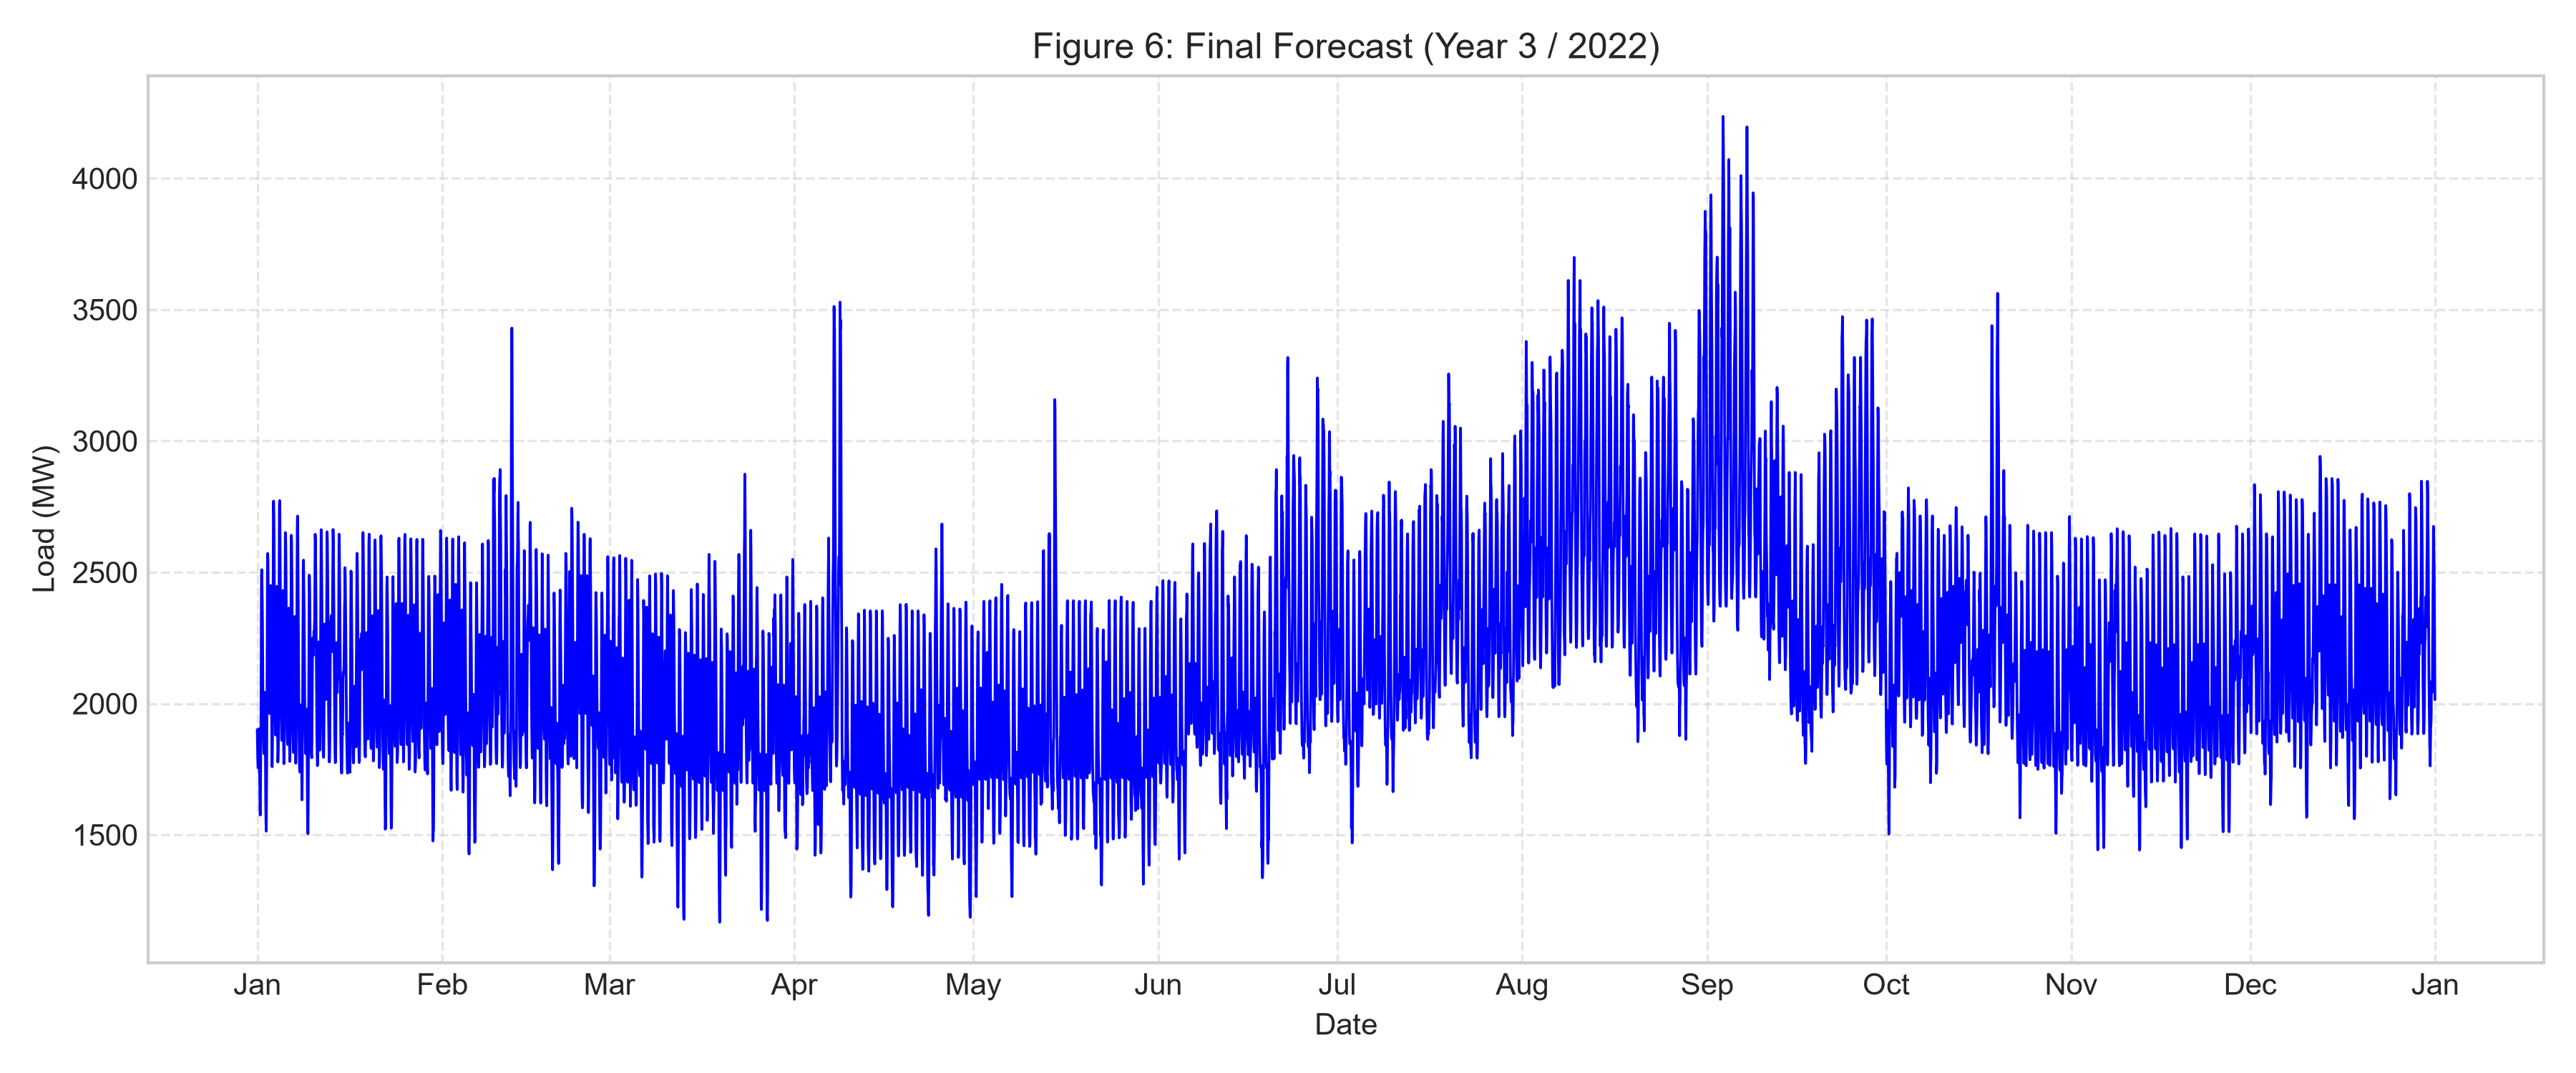

=== Figure 7: Monthly Forecast Grid (with 24h Moving Average) ===


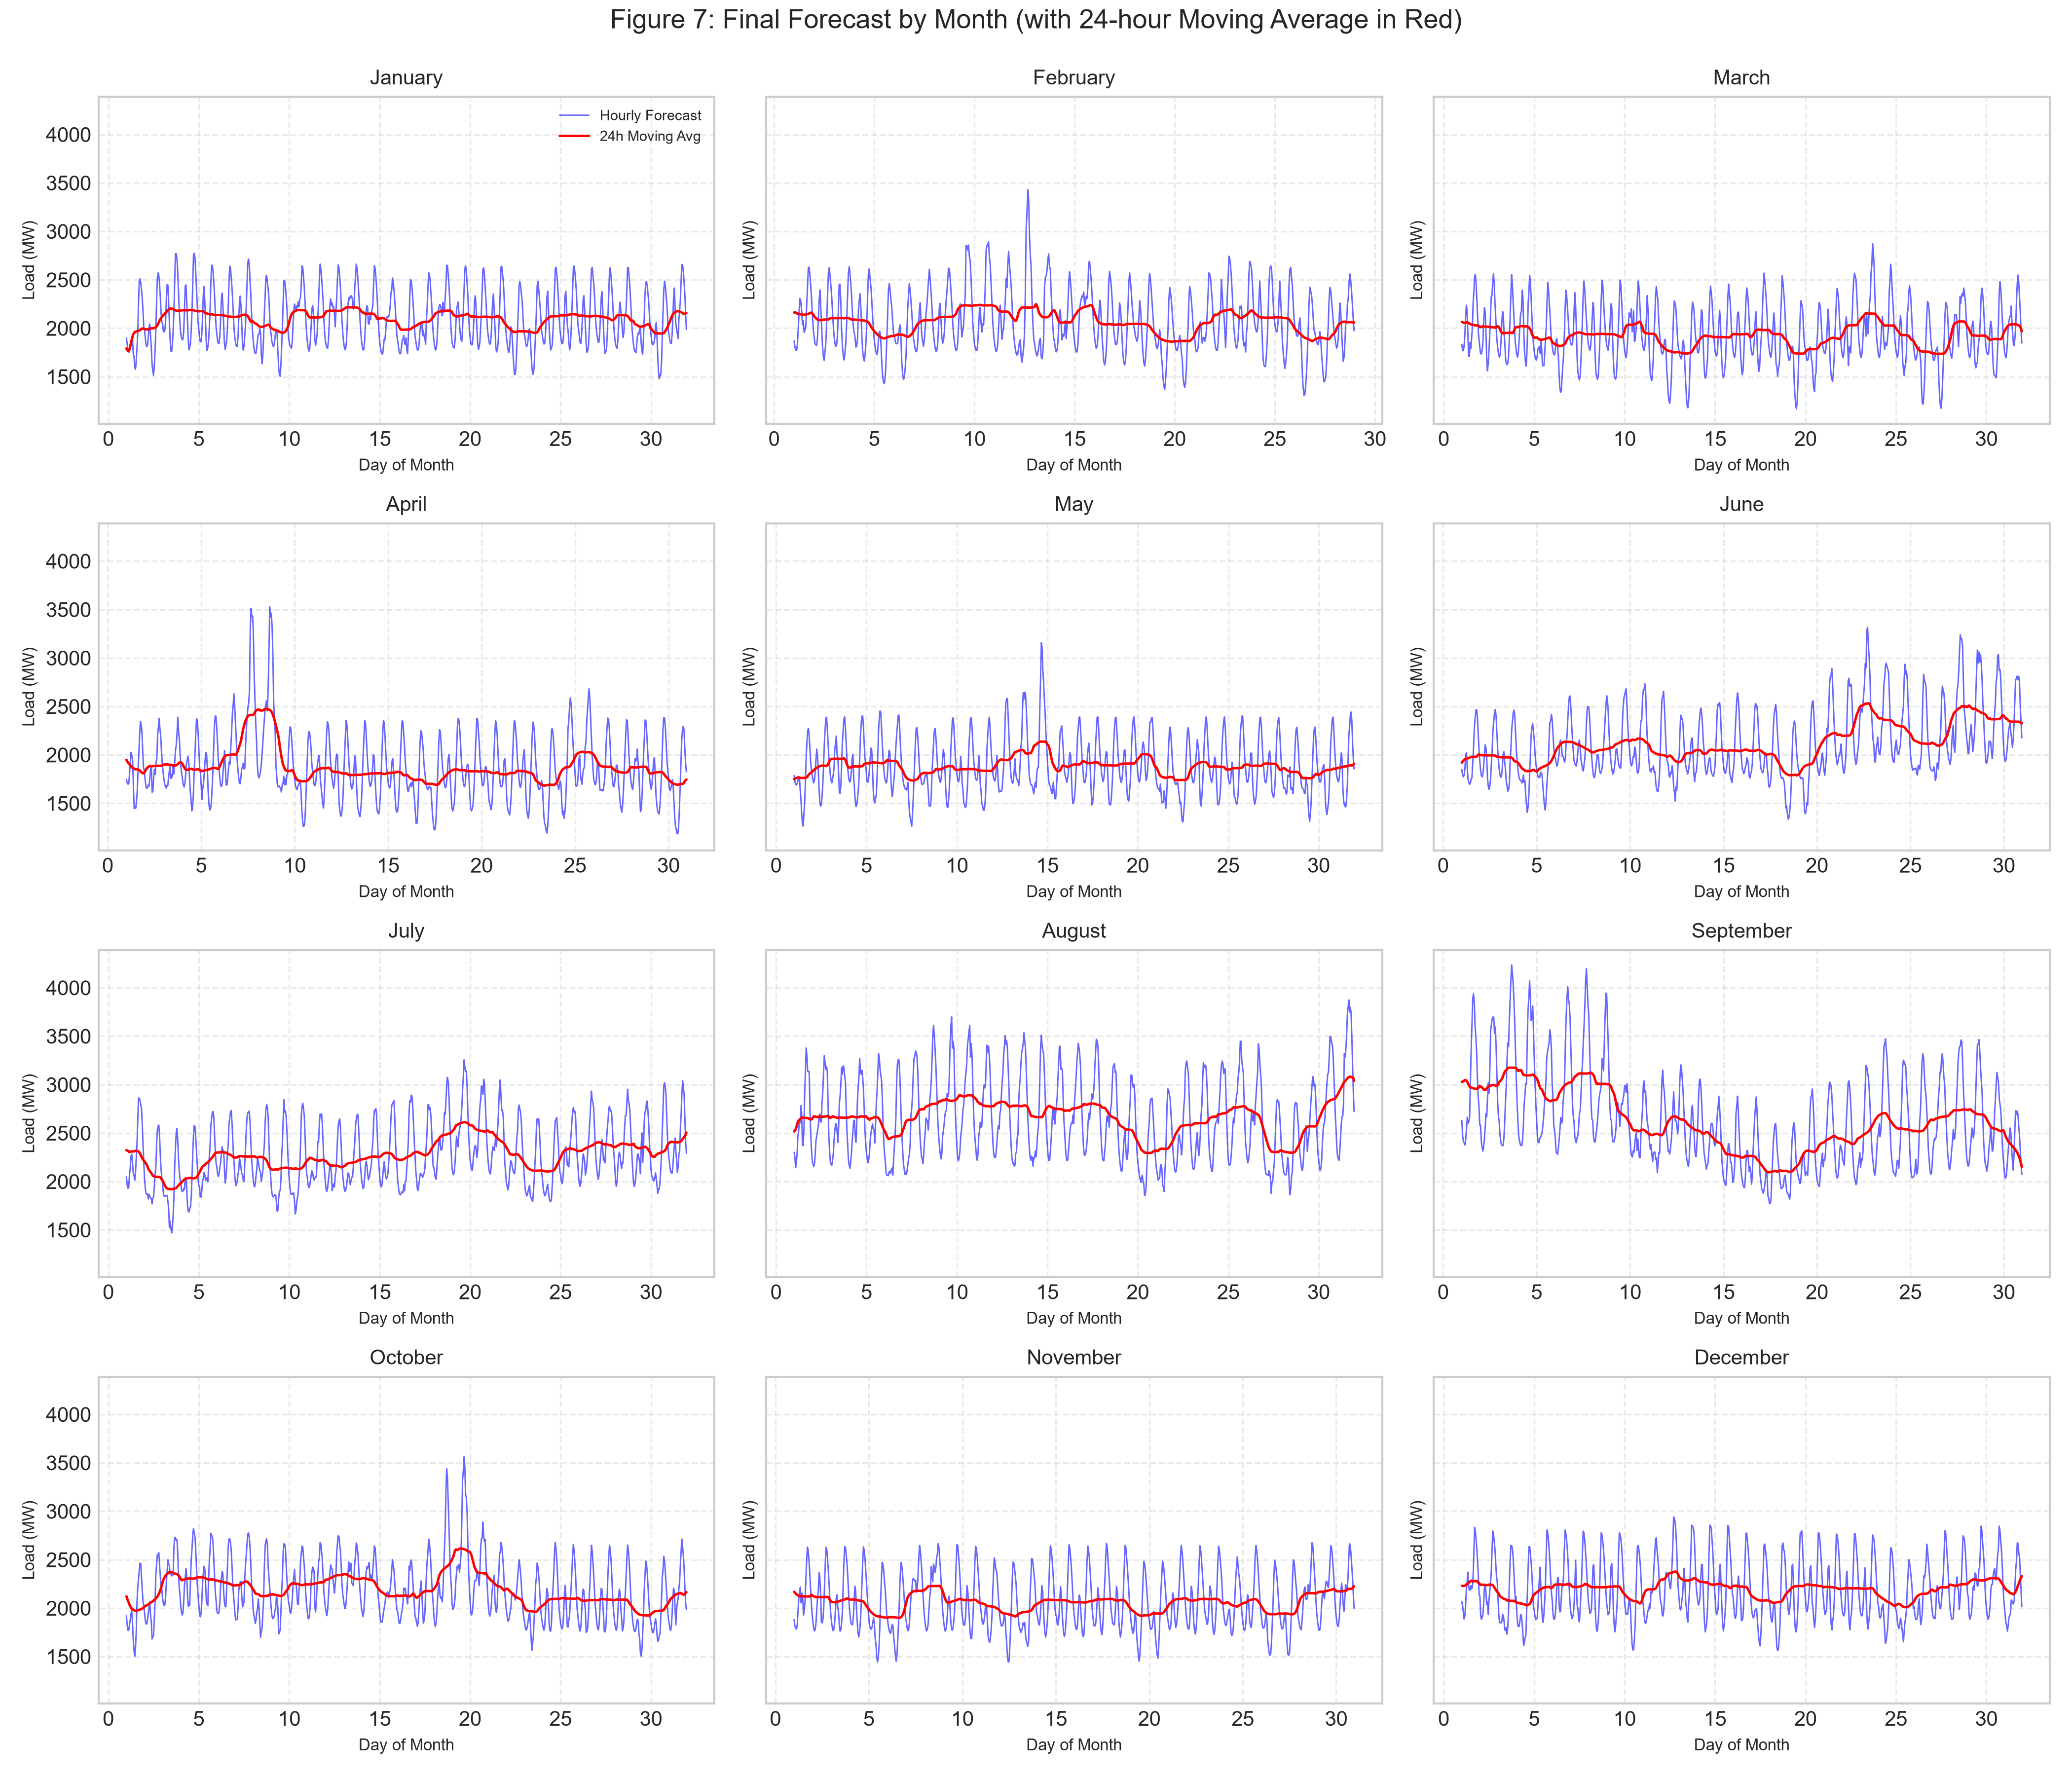


Replication notebook execution completed successfully!


In [9]:
plot_fig6_final_forecast(test_df, y3_preds, FIGURES_DIR)
plot_fig7_monthly_forecast(test_df, y3_preds, FIGURES_DIR)

fig6_path = os.path.join(FIGURES_DIR, "Figure_6_Final_Forecast.png")
fig7_path = os.path.join(FIGURES_DIR, "Figure_7_Final_Forecast_by_Month.png")

print("=== Figure 6: Final Load Forecast (Year 3 / 2022) ===")
display(Image(filename=fig6_path, width=850))

print("=== Figure 7: Monthly Forecast Grid (with 24h Moving Average) ===")
display(Image(filename=fig7_path, width=850))

print("\nReplication notebook execution completed successfully!")
